# 04 — Statistical Analysis

*Executed analytical companion to the validated production pipeline.*

## Objective

Present the prespecified non-parametric hypotheses, Holm-adjusted evidence, effect sizes, and limitations from the reusable statistical-analysis phase.

## Business Questions

- Which customer metrics move together monotonically?
- How different are repeat and one-time customer-value distributions?
- How different are UK and international order-value distributions?
- Is repeat status associated with UK versus international geography?

## Inputs

- `reports/statistics/hypothesis_tests.csv`
- `reports/statistics/correlation_matrix.csv`
- `reports/statistics/statistical_summary.json`
- Existing charts under `images/statistics/`
- Statistical constants from `retail_analytics.statistical_analysis`

## Methodology

Read executed test outputs rather than rerunning them. Spearman tests address monotonic association, Mann–Whitney U tests compare distributions, and Pearson's chi-square test assesses categorical independence. Holm correction controls family-wise error within the correlation and confirmatory-test families.

## Code

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = next(
    path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (path / "src" / "retail_analytics").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_rows", 12)
pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 140)

def load_json(relative_path):
    return json.loads((PROJECT_ROOT / relative_path).read_text(encoding="utf-8"))

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")

from retail_analytics.statistical_analysis import ALPHA, CORRELATION_FEATURES

tests = pd.read_csv(PROJECT_ROOT / "reports" / "statistics" / "hypothesis_tests.csv")
correlations = pd.read_csv(
    PROJECT_ROOT / "reports" / "statistics" / "correlation_matrix.csv", index_col=0
)
summary = load_json("reports/statistics/statistical_summary.json")
print(f"Tests reported: {len(tests)}; alpha={ALPHA}")

Project root: C:\Projects\Retail-Customer-Intelligence-Analytics
Python: 3.12.7


Tests reported: 24; alpha=0.05


In [2]:
confirmatory = tests.loc[tests["family"].eq("confirmatory_group_tests")].copy()
hypotheses = confirmatory[
    ["test_name", "comparison", "null_hypothesis", "alternative_hypothesis", "sample_size_total"]
]
display(hypotheses)

,test_name,comparison,null_hypothesis,alternative_hypothesis,sample_size_total
21,Mann-Whitney U,Customer monetary value: repeat versus one-tim...,Repeat and one-time customers have the same mo...,Repeat and one-time customers have different m...,5878
22,Mann-Whitney U,Order value: United Kingdom versus internation...,UK and international orders have the same orde...,UK and international orders have different ord...,40077
23,Pearson chi-square test of independence,Repeat-customer status: United Kingdom versus ...,Repeat-customer status is independent of UK ve...,Repeat-customer status is associated with UK v...,5878


In [3]:
display(correlations.round(3))
strongest = (
    tests.loc[tests["family"].eq("spearman_correlations")]
    .assign(abs_effect=lambda frame: frame["effect_size"].abs())
    .nlargest(8, "abs_effect")
    [["comparison", "statistic", "adjusted_p_value", "effect_magnitude"]]
    .copy()
)
strongest["statistic"] = strongest["statistic"].map(lambda value: f"{value:.3f}")
strongest["adjusted_p_value"] = strongest["adjusted_p_value"].map(
    lambda value: "< machine precision" if value == 0 else f"{value:.3e}"
)
display(strongest)

,recency_days,frequency_orders,monetary_value_gbp,average_order_value_gbp,active_span_days,units_purchased,distinct_products
recency_days,1.000,-0.561,-0.512,-0.173,-0.570,-0.518,-0.472
frequency_orders,-0.561,1.000,0.858,0.209,0.883,0.820,0.724
monetary_value_gbp,-0.512,0.858,1.000,0.651,0.763,0.941,0.768
average_order_value_gbp,-0.173,0.209,0.651,1.000,0.205,0.602,0.417
active_span_days,-0.570,0.883,0.763,0.205,1.000,0.733,0.661
units_purchased,-0.518,0.820,0.941,0.602,0.733,1.000,0.765
distinct_products,-0.472,0.724,0.768,0.417,0.661,0.765,1.000


,comparison,statistic,adjusted_p_value,effect_magnitude
13,monetary_value_gbp versus units_purchased,0.941,< machine precision,large
8,frequency_orders versus active_span_days,0.883,< machine precision,large
6,frequency_orders versus monetary_value_gbp,0.858,< machine precision,large
9,frequency_orders versus units_purchased,0.820,< machine precision,large
14,monetary_value_gbp versus distinct_products,0.768,< machine precision,large
20,units_purchased versus distinct_products,0.765,< machine precision,large
12,monetary_value_gbp versus active_span_days,0.763,< machine precision,large
18,active_span_days versus units_purchased,0.733,< machine precision,large


## Results

In [4]:
result_view = confirmatory[
    ["comparison", "sample_size_group_1", "sample_size_group_2", "group_1_summary", "group_2_summary",
     "statistic_name", "statistic", "raw_p_value", "adjusted_p_value", "effect_size_name",
     "effect_size", "effect_magnitude", "reject_null"]
].copy()
for column in ["raw_p_value", "adjusted_p_value"]:
    result_view[column] = result_view[column].map(
        lambda value: "< machine precision" if value == 0 else f"{value:.3e}"
    )
result_view["statistic"] = result_view["statistic"].map(lambda value: f"{value:,.3f}")
result_view["effect_size"] = result_view["effect_size"].map(lambda value: f"{value:.3f}")
display(result_view)

interpretations = confirmatory[["comparison", "business_interpretation", "limitations"]]
display(interpretations)

,comparison,sample_size_group_1,sample_size_group_2,group_1_summary,group_2_summary,statistic_name,statistic,raw_p_value,adjusted_p_value,effect_size_name,effect_size,effect_magnitude,reject_null
21,Customer monetary value: repeat versus one-tim...,4255.0,1623.0,median_gbp=1370.48,median_gbp=228.96,Mann-Whitney U,"6,350,192.000",< machine precision,< machine precision,Rank-biserial correlation,0.839,large,True
22,Order value: United Kingdom versus internation...,36535.0,3542.0,median_gbp=296.10,median_gbp=450.50,Mann-Whitney U,"46,075,248.500",1.264e-176,2.528e-176,Rank-biserial correlation,-0.288,small,True
23,Repeat-customer status: United Kingdom versus ...,5350.0,528.0,repeat_proportion=0.7245,repeat_proportion=0.7178,Chi-square,0.107,7.431e-01,7.431e-01,Cramer's V,0.004,negligible,False


,comparison,business_interpretation,limitations
21,Customer monetary value: repeat versus one-tim...,"Repeat customers have a median value of GBP 1,...",Customer value accumulates over unequal observ...
22,Order value: United Kingdom versus internation...,Median UK order value is GBP 296.10 versus GBP...,Orders from the same customer are not fully in...
23,Repeat-customer status: United Kingdom versus ...,Repeat rates are 72.4% for UK customers and 71...,Primary country compresses multi-country histo...


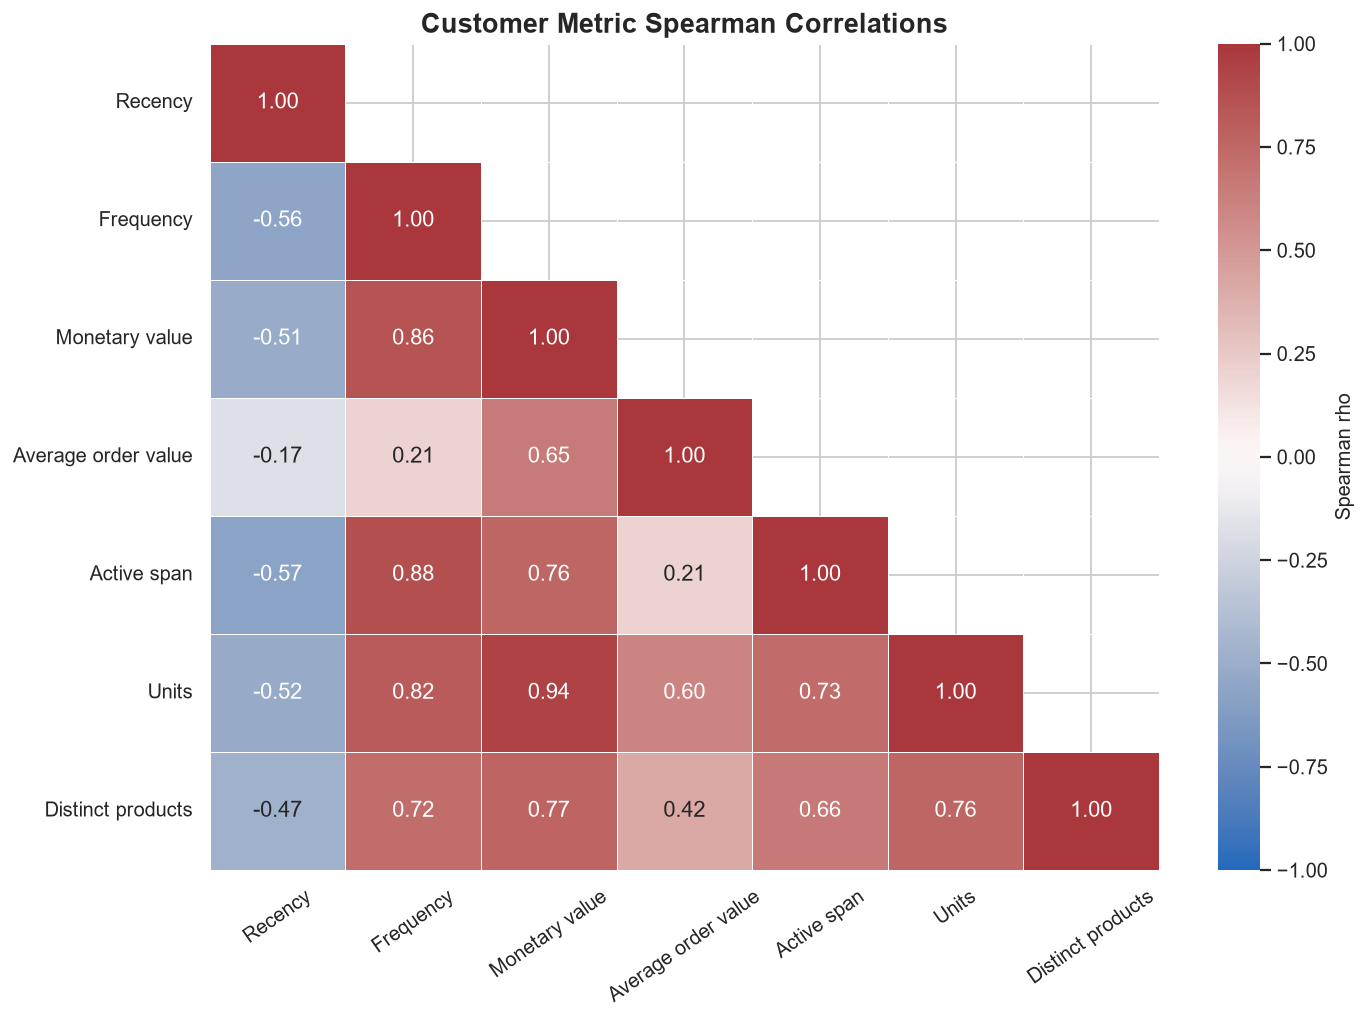

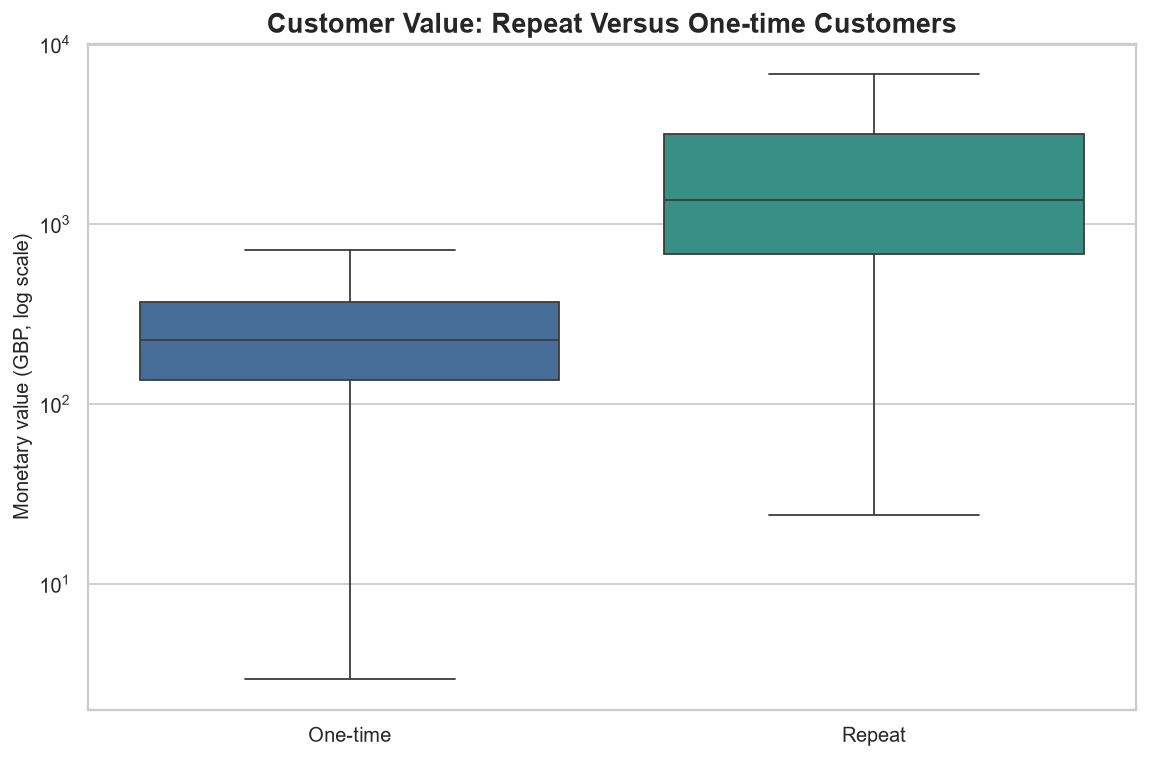

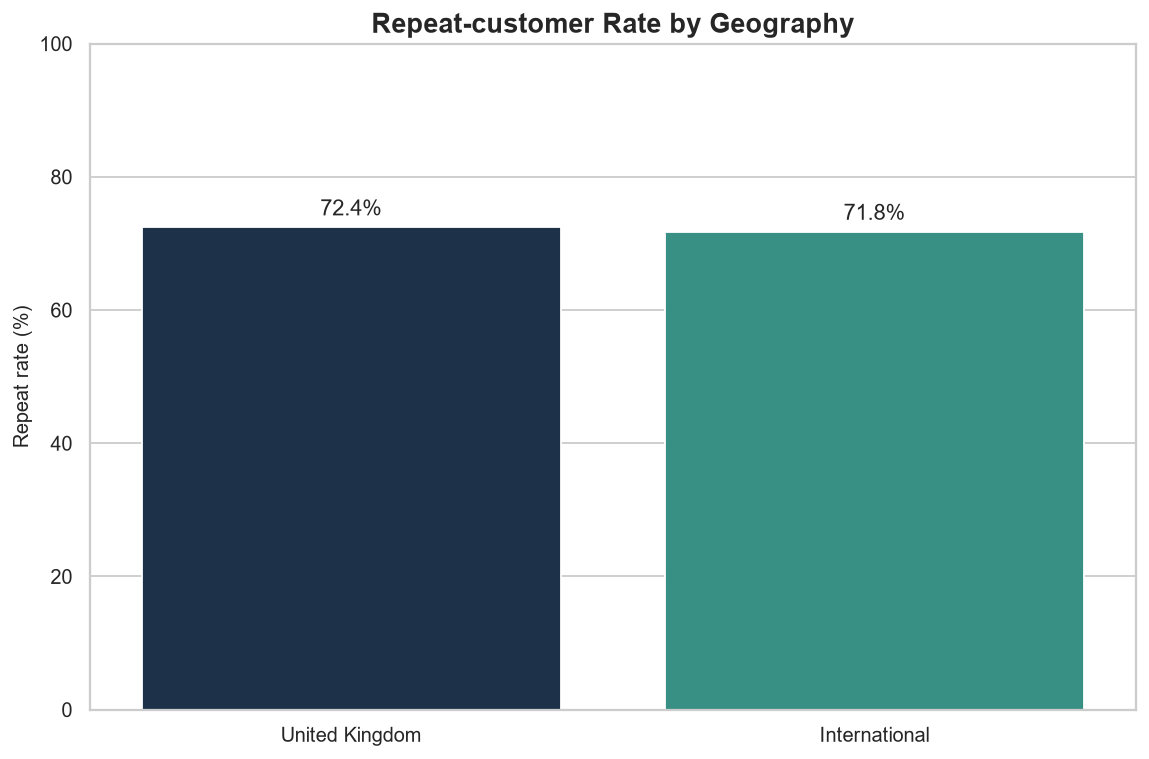

In [5]:
for chart in [
    "images/statistics/01_spearman_correlation_heatmap.png",
    "images/statistics/02_repeat_customer_value_comparison.png",
    "images/statistics/04_geographic_repeat_rate.png",
]:
    display(Image(filename=str(PROJECT_ROOT / chart), width=850))

## Business Insights

- Repeat customers have much higher observed monetary value than one-time customers, with a **large** rank-biserial effect; the result is commercially more informative than its extremely small p-value alone.
- International orders have a higher median value than UK orders, but the rank-biserial effect is **small**, so market volume, fulfilment cost, and mix remain important.
- UK versus international repeat rates are nearly identical; Cramer's V is negligible and the adjusted p-value does not support an association.
- Strong correlations among frequency, value, units, and active span reflect related behavior, not proof that changing one will cause another to change.

## Assumptions

- Observations meet the operational definitions in the validated RFM and order reports.
- Holm correction is applied within the two prespecified hypothesis families.
- Effect-size direction follows the documented group ordering.

## Limitations

- The analysis is observational and cannot identify causal effects.
- Repeat orders from the same customer weaken strict order-level independence.
- Large samples can make small effects statistically significant; effect magnitude and business cost must guide decisions.
- Unequal customer exposure time and wholesale-like activity can influence ranks.

## Next Steps

- Define practical effect thresholds before campaign decisions.
- Use experiments to estimate causal response to retention actions.
- Add margin and fulfilment measures before interpreting geographic value differences commercially.